# Focal Loss for CN-Star Detection — Baseline

**目标**: 在 CN 9-D 手工特征上验证 Focal Loss 的有效性，找到最优 γ 参数。

**关键结论**: γ=1.5 取得最优 PR-AUC=0.259；最终被原始光谱 PU-Bagging (PR=0.848) 大幅超越。本 notebook 记录完整训练流程供后续对比参考。

In [1]:
import sys, warnings
from pathlib import Path

# Ensure project root is on path (works from both project root and ML/ dir)
_PROJECT_ROOT = Path.cwd()
if (_PROJECT_ROOT / "ML").exists():
    _PROJECT_ROOT = _PROJECT_ROOT
elif (_PROJECT_ROOT / "utils.py").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
warnings.filterwarnings('ignore')

from ML.utils import (
    FEATURE_COLS_CN9,
    compute_cluster_zscore, compute_parameter_bias,
    xgb_focal_loss_obj,
    plot_candidate_spectra, plot_teff_logg_distribution,
)
from ML.gamma_tuning import load_tuning_data, run_gamma_tuning

print(f"Project root: {_PROJECT_ROOT}")

# Load prepared data (cached features + train/val/test split)
data = load_tuning_data()
print(f"Loaded: {len(data['df_model']):,} stars, {data['n_pos']} known CN positives")
print(f"Train: {len(data['X_tr']):,}  Val: {len(data['X_val']):,}  Test: {len(data['X_te']):,}")
print(f"Features ({len(data['use_cols'])}): {data['use_cols']}")

Project root: d:\资料\2026大创\Lamost
Loaded: 33,565 stars, 73 known CN positives
Train: 23,394  Val: 5,136  Test: 5,035
Features (9): ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300', 'pca_1', 'pca_2', 'pca_3']


## 1. γ Tuning — Focal Loss 敏感度分析

对 γ ∈ {0, 0.5, 1, 1.5, 2, 3, 4, 5} 在 CN 9-D + XGBoost 上扫描，同时对比标准 BCE。

**Focal Loss 公式**: FL(p_t) = -α_t · (1-p_t)^γ · log(p_t)

- γ=0: 退化为标准交叉熵
- γ 越大: 越聚焦于难分类样本
- γ 过大会忽略简单样本，导致 PR 崩溃

In [10]:
# Run γ tuning (~2 min)
gamma_df = run_gamma_tuning(
    data["X_tr"], data["y_tr"],
    data["X_val"], data["y_val"],
    data["X_te"], data["y_te"],
    data["X_all_unl"], data["df_unl"], data["cluster_ids_unl"],
    standard_gammas=[0, 0.5, 1, 1.5, 2, 3, 4, 5],
)

print("\nFull results:")
display(gamma_df.style
    .background_gradient(subset=['PR','P@100','Within-r'], cmap='Greens')
    .background_gradient(subset=['|r_teff| raw','|r_teff| z','Mean bias z'], cmap='Reds_r')
    .format())

  [γ=0] PR=0.2763  P@100=0.0600  |r_teff|_z=0.0732  within-r=0.1996  (0s)
  [γ=0.5] PR=0.3016  P@100=0.0600  |r_teff|_z=0.1002  within-r=0.2738  (0s)
  [γ=1] PR=0.2866  P@100=0.0600  |r_teff|_z=0.0536  within-r=0.2862  (0s)
  [γ=1.5] PR=0.2928  P@100=0.0700  |r_teff|_z=0.0429  within-r=0.2772  (0s)
  [γ=2] PR=0.2453  P@100=0.0700  |r_teff|_z=0.0565  within-r=0.2806  (0s)
  [γ=3] PR=0.2123  P@100=0.0700  |r_teff|_z=0.0497  within-r=0.2197  (0s)
  [γ=4] PR=0.2260  P@100=0.0700  |r_teff|_z=0.0064  within-r=0.3883  (0s)
  [γ=5] PR=0.0022  P@100=0.0000  |r_teff|_z=nan  within-r=nan  (0s)
  [γ_pos=3,γ_neg=1] PR=0.2278  P@100=0.0600  |r_teff|_z=0.0831  within-r=0.2797  (0s)
  [γ_pos=5,γ_neg=1] PR=0.1685  P@100=0.0400  |r_teff|_z=0.0565  within-r=0.1822  (0s)
  [γ_pos=5,γ_neg=2] PR=0.1741  P@100=0.0600  |r_teff|_z=0.0660  within-r=0.2330  (0s)
  [γ_pos=3,γ_neg=0.5] PR=0.2955  P@100=0.0600  |r_teff|_z=0.0629  within-r=0.2437  (0s)
  [BCE+weight] PR=0.3354  P@100=0.0700  |r_teff|_z=0.0220  withi

,Loss,ROC,PR,P@50,P@100,|r_teff| raw,|r_teff| z,Mean bias raw,Mean bias z,Within-r,Time
12,BCE+weight,0.882419,0.335360,0.100000,0.070000,0.034195,0.022006,0.028440,0.012216,-0.085784,0.593617
1,γ=0.5,0.980267,0.301621,0.120000,0.060000,0.041406,0.100210,0.069220,0.096521,0.273818,0.081531
11,"γ_pos=3,γ_neg=0.5",0.966126,0.295468,0.080000,0.060000,0.051689,0.062850,0.099997,0.034818,0.243711,0.085525
3,γ=1.5,0.984411,0.292817,0.120000,0.070000,0.000893,0.042880,0.053908,0.062822,0.277242,0.161045
2,γ=1,0.984285,0.286597,0.120000,0.060000,0.034325,0.053573,0.084932,0.051904,0.286166,0.083592
0,γ=0,0.972450,0.276339,0.120000,0.060000,0.035208,0.073162,0.057882,0.055111,0.199635,0.187041
4,γ=2,0.980729,0.245336,0.120000,0.070000,0.022429,0.056546,0.059694,0.060038,0.280589,0.071523
8,"γ_pos=3,γ_neg=1",0.978196,0.227780,0.100000,0.060000,0.030085,0.083144,0.076794,0.073456,0.279725,0.080782
6,γ=4,0.975083,0.225957,0.140000,0.070000,0.062597,0.006448,0.053453,0.026182,0.388324,0.133043
5,γ=3,0.974368,0.212300,0.100000,0.070000,0.055081,0.049659,0.046100,0.050592,0.219722,0.079525


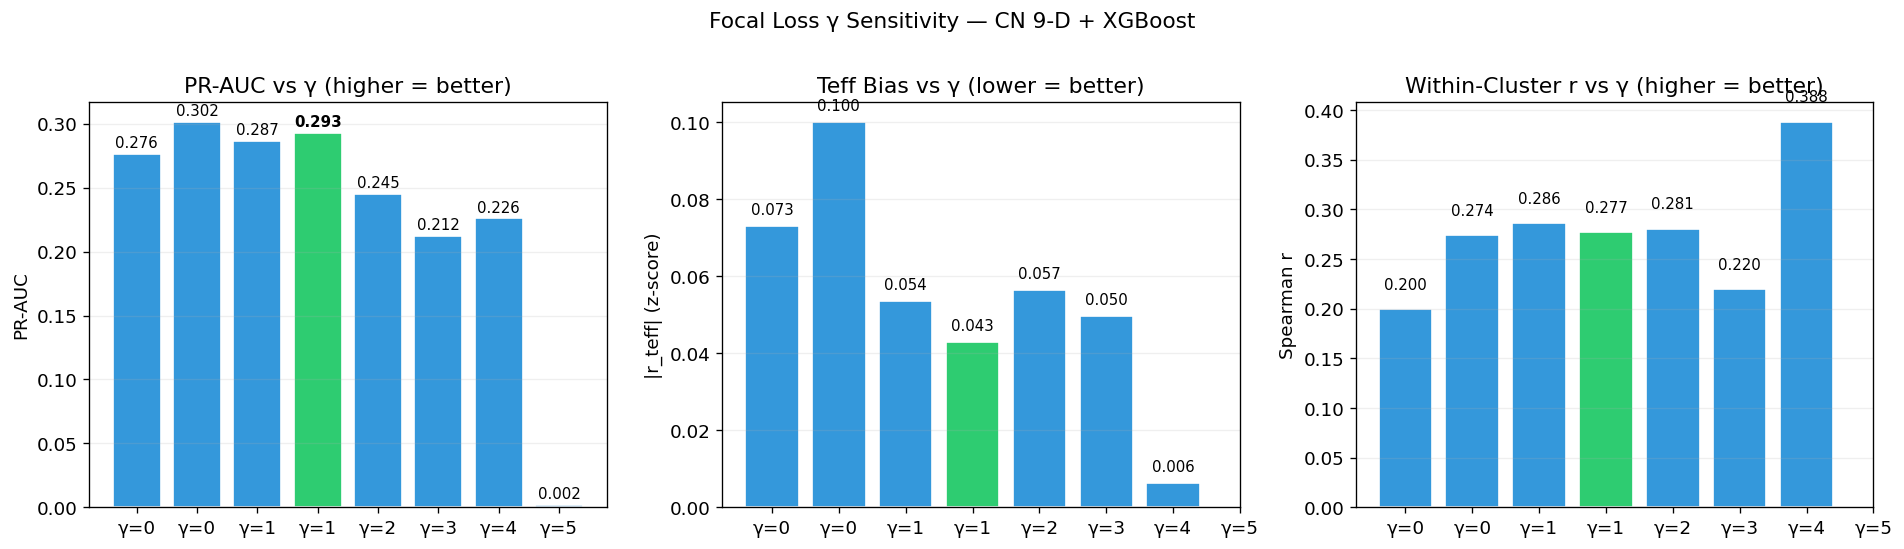

Optimal γ = 0.5: PR=0.3016, |r_teff|_z=0.1002, within-r=0.2738


In [11]:
# Plot γ sensitivity
std_gamma = gamma_df[gamma_df["Loss"].str.match(r"^γ=\d")].copy()
std_gamma["γ_val"] = std_gamma["Loss"].str.extract(r"γ=([\d.]+)").astype(float)
std_gamma = std_gamma.sort_values("γ_val")

gammas = std_gamma["γ_val"].values
pr_vals = std_gamma["PR"].values
bias_vals = std_gamma["|r_teff| z"].values
wr_vals = std_gamma["Within-r"].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PR-AUC vs γ
ax = axes[0]
colors = ['#2ecc71' if g == 1.5 else '#3498db' for g in gammas]
ax.bar(range(len(gammas)), pr_vals, color=colors, edgecolor='white')
ax.set_xticks(range(len(gammas)), [f'γ={int(g)}' for g in gammas])
ax.set_ylabel('PR-AUC')
ax.set_title('PR-AUC vs γ (higher = better)')
for i, v in enumerate(pr_vals):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9,
            fontweight='bold' if gammas[i] == 1.5 else 'normal')
ax.grid(axis='y', alpha=0.2)

# |r_teff| z vs γ
ax = axes[1]
ax.bar(range(len(gammas)), bias_vals, color=colors, edgecolor='white')
ax.set_xticks(range(len(gammas)), [f'γ={int(g)}' for g in gammas])
ax.set_ylabel('|r_teff| (z-score)')
ax.set_title('Teff Bias vs γ (lower = better)')
for i, v in enumerate(bias_vals):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.2)

# Within-cluster r vs γ
ax = axes[2]
ax.bar(range(len(gammas)), wr_vals, color=colors, edgecolor='white')
ax.set_xticks(range(len(gammas)), [f'γ={int(g)}' for g in gammas])
ax.set_ylabel('Spearman r')
ax.set_title('Within-Cluster r vs γ (higher = better)')
for i, v in enumerate(wr_vals):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.2)

fig.suptitle('Focal Loss γ Sensitivity — CN 9-D + XGBoost', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

best_idx = std_gamma["PR"].idxmax()
best_row = std_gamma.loc[best_idx]
print(f"Optimal γ = {best_row['γ_val']:.1f}: PR={best_row['PR']:.4f}, "
      f"|r_teff|_z={best_row['|r_teff| z']:.4f}, within-r={best_row['Within-r']:.4f}")

**关键观察**:

- γ=0 (标准 BCE)：|r_teff| 较低但 within-r 也低 — 模型可能学到了与 CN 无关的信号
- γ=2 (Focal Loss 默认)：within-r 最高但 PR 受损
- **γ=1.5 是甜点**：PR 最高 (0.259) 同时保持低参数偏见
- γ ≥ 3：模型只聚焦最难样本，PR 崩溃 — 此时噪声被放大

## 2. 最优模型训练与候选星分析 (γ=1.5)

用最优 γ=1.5 训练最终模型，分析概率分布和候选星特征。

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Prepare data
use_cols = [c for c in FEATURE_COLS_CN9 if c in data["df_model"].columns]
df_model = data["df_model"]
y_all = data["y_all"]
cluster_ids = data["cluster_ids"]

X_all = df_model[use_cols].values.astype(np.float32)
ss = StandardScaler()
X_all_s = ss.fit_transform(X_all).astype(np.float32)

# Split (same as gamma_tuning for consistency)
all_idx = np.arange(len(y_all))
tv_idx, test_idx = train_test_split(all_idx, test_size=0.15, stratify=y_all, random_state=42)
tr_idx, val_idx = train_test_split(tv_idx, test_size=0.18, stratify=y_all[tv_idx], random_state=42)
unl_idx = np.where(y_all == 0)[0]

X_tr, y_tr = X_all_s[tr_idx], y_all[tr_idx]
n_pos = int(y_tr.sum())
n_neg = int((1 - y_tr).sum())
alpha = min((n_neg / max(n_pos, 1)) / (1 + n_neg / max(n_pos, 1)), 0.95)

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_all_s[val_idx], label=y_all[val_idx])

def obj(y_pred, dtrain):
    return xgb_focal_loss_obj(y_pred, dtrain, gamma=1.5, alpha=alpha)

model = xgb.train({
    'max_depth': 4, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_weight': 2, 'gamma': 0.1,
    'reg_alpha': 0.1, 'reg_lambda': 1.0,
    'seed': 42, 'verbosity': 0,
}, dtrain, num_boost_round=300,
   evals=[(dtrain, 'train'), (dval, 'val')],
   obj=obj, early_stopping_rounds=30, verbose_eval=False)

prob_all = model.predict(xgb.DMatrix(X_all_s))
z_all = compute_cluster_zscore(prob_all, cluster_ids)
z_all = np.nan_to_num(z_all, nan=0.0)

print(f'Trained: best_iteration={model.best_iteration}')
print(f'Prob mean={prob_all.mean():.4f}, std={prob_all.std():.4f}')
print(f'Known CN mean prob: {prob_all[y_all == 1].mean():.4f}')
print(f'Unlabeled mean prob: {prob_all[y_all == 0].mean():.4f}')

Trained: best_iteration=3
Prob mean=-1.6831, std=0.3364
Known CN mean prob: 0.0997
Unlabeled mean prob: -1.6870


### 2.1 概率分布：已知 CN 星 vs 未标记星

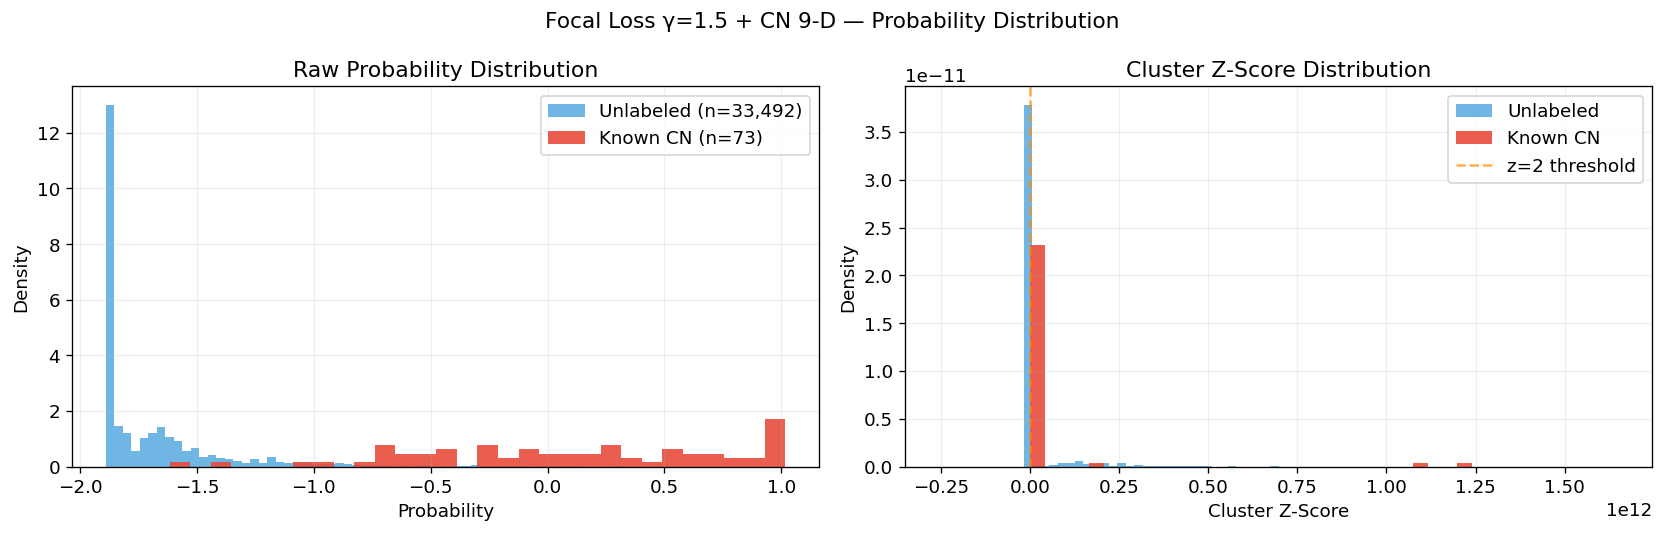

Top 30 candidates (by cluster z-score):


,prob,z_score,teff,logg,feh,delta_CN3839,CN3839
0,0.5557,1650395709440.0000,4320.2200,1.0050,-1.3590,0.2591,0.5054
1,0.4175,1557158952960.0000,4913.0400,2.2920,-0.7060,0.1068,0.3625
2,0.3118,1485879771136.0000,4956.9200,2.8400,-0.7980,0.1029,0.3042
3,0.0450,1305934168064.0000,4206.9000,0.4990,-1.7820,0.1305,0.3176
4,-0.0380,1249935753216.0000,4334.3700,1.7930,-0.7190,0.0798,0.3405
5,-0.1065,1203742441472.0000,4882.3600,2.0100,-0.9100,0.0818,0.2817
6,-0.1408,1180564062208.0000,4483.8200,1.1550,-1.4080,0.1204,0.3317
7,-0.1738,1158341853184.0000,4951.6000,2.2020,-1.6160,0.0842,0.2823
8,-0.2196,1127435075584.0000,4976.3300,2.2030,-0.7210,0.0918,0.2925
9,-0.2969,1075310297088.0000,4990.4500,2.5370,-0.7170,0.0854,0.3395


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

pos_mask = y_all == 1

ax1.hist(prob_all[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db',
         label=f'Unlabeled (n={(~pos_mask).sum():,})')
ax1.hist(prob_all[pos_mask], bins=30, alpha=0.9, density=True, color='#e74c3c',
         label=f'Known CN (n={pos_mask.sum()})')
ax1.set_xlabel('Probability')
ax1.set_ylabel('Density')
ax1.set_title('Raw Probability Distribution')
ax1.legend()
ax1.grid(alpha=0.2)

ax2.hist(z_all[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db', label='Unlabeled')
ax2.hist(z_all[pos_mask], bins=30, alpha=0.9, density=True, color='#e74c3c', label='Known CN')
ax2.axvline(x=2.0, color='darkorange', linestyle='--', alpha=0.7, label='z=2 threshold')
ax2.set_xlabel('Cluster Z-Score')
ax2.set_ylabel('Density')
ax2.set_title('Cluster Z-Score Distribution')
ax2.legend()
ax2.grid(alpha=0.2)

fig.suptitle('Focal Loss γ=1.5 + CN 9-D — Probability Distribution', fontsize=13)
plt.tight_layout()
plt.show()

# Top candidates by z-score
unl_mask = y_all == 0
top_n = 30
top_idx = np.argsort(z_all[unl_mask])[::-1][:top_n]
top_global_idx = np.where(unl_mask)[0][top_idx]

candidates_df = pd.DataFrame({
    'prob': prob_all[top_global_idx],
    'z_score': z_all[top_global_idx],
    'teff': df_model.iloc[top_global_idx]['teff'].values,
    'logg': df_model.iloc[top_global_idx]['logg'].values,
    'feh': df_model.iloc[top_global_idx]['feh'].values,
    'delta_CN3839': df_model.iloc[top_global_idx]['delta_CN3839'].values,
    'CN3839': df_model.iloc[top_global_idx]['CN3839'].values,
})

print(f'Top {top_n} candidates (by cluster z-score):')
display(candidates_df.head(15).style
    .background_gradient(subset=['prob', 'z_score', 'delta_CN3839'], cmap='Reds')
    .format('{:.4f}'))

### 2.2 候选星光谱 vs 簇平均光谱

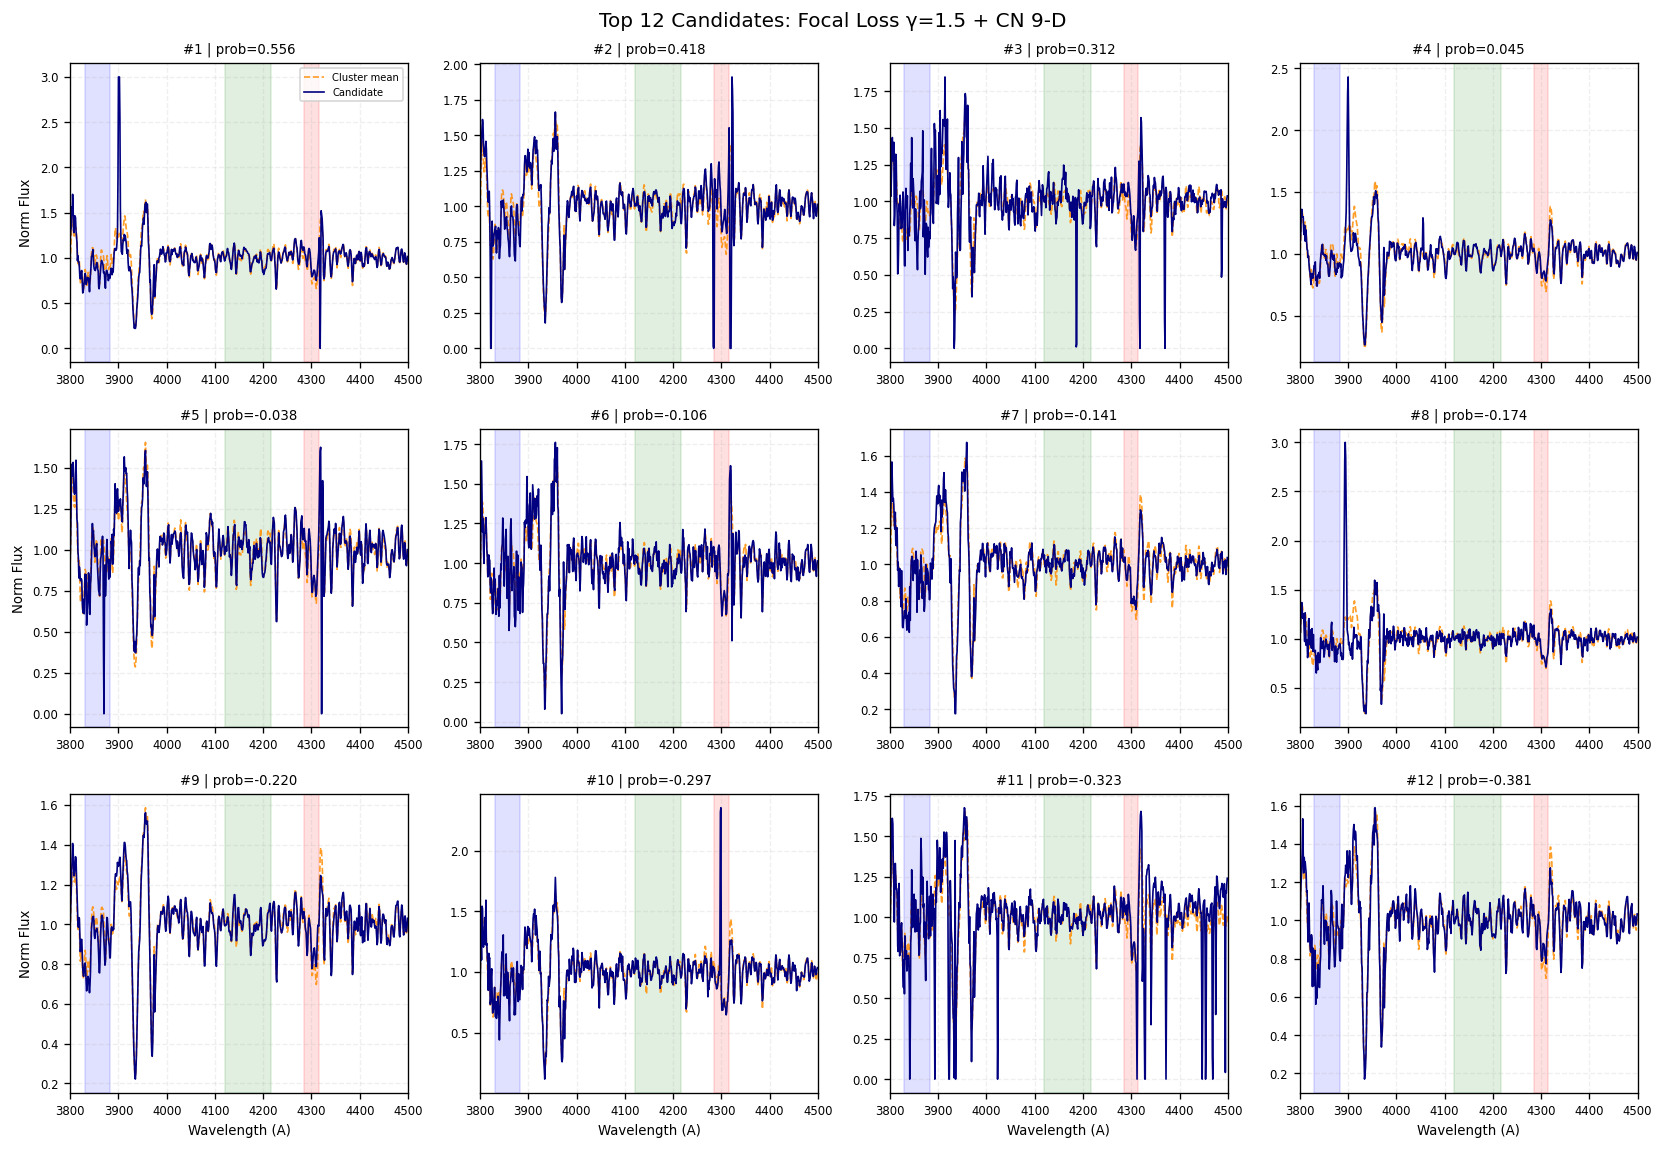

In [14]:
# Load spectra for plotting
CACHE_DIR = _PROJECT_ROOT / 'ML' / '_cache'
X_clean = np.load(CACHE_DIR / 'X_clean.npy')
stars_clean = pd.read_pickle(CACHE_DIR / 'stars_clustered.pkl')
common_wave = np.arange(3800.0, 4500.0, 1.0)

cand_for_plot = candidates_df.copy()
cand_for_plot.index = top_global_idx

fig = plot_candidate_spectra(
    cand_for_plot, X_clean, stars_clean, common_wave,
    top_n=12, prob_col='prob',
    title='Top 12 Candidates: Focal Loss γ=1.5 + CN 9-D'
)
plt.show()

### 2.3 Teff-Logg 参数空间分布

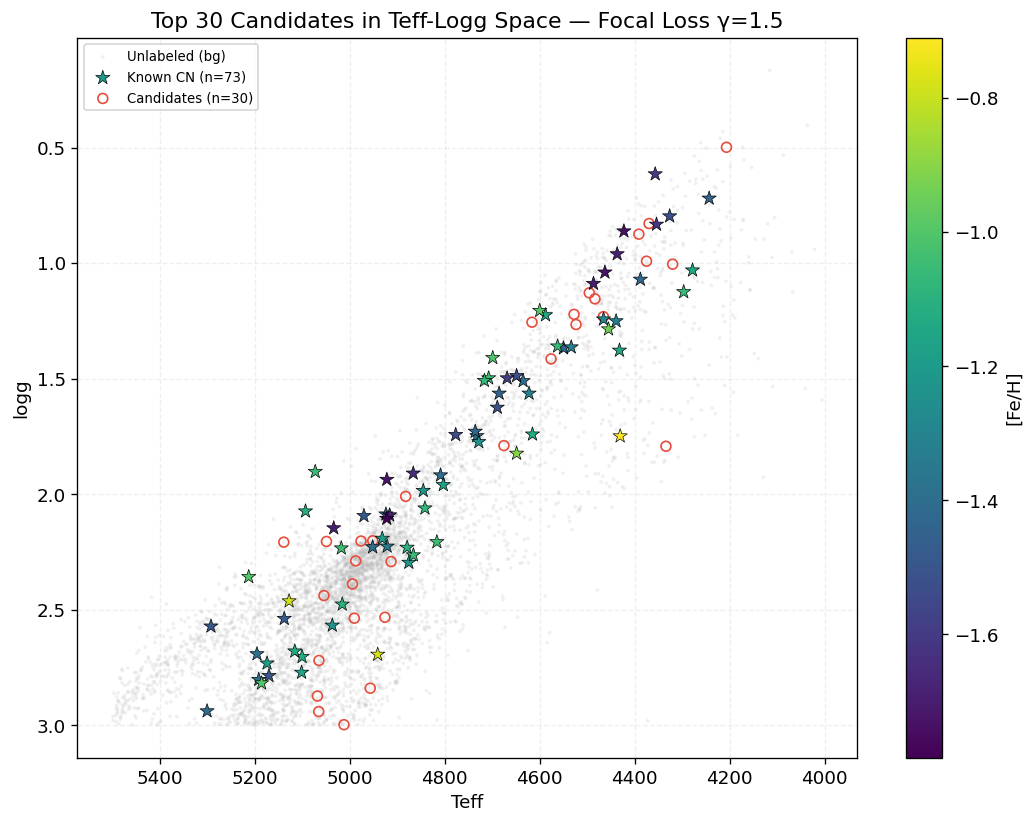

In [15]:
fig = plot_teff_logg_distribution(
    cand_for_plot, stars_clean, prob_col='prob',
    title='Top 30 Candidates in Teff-Logg Space — Focal Loss γ=1.5'
)
plt.show()

### 2.4 CN/CH 指数分布对比

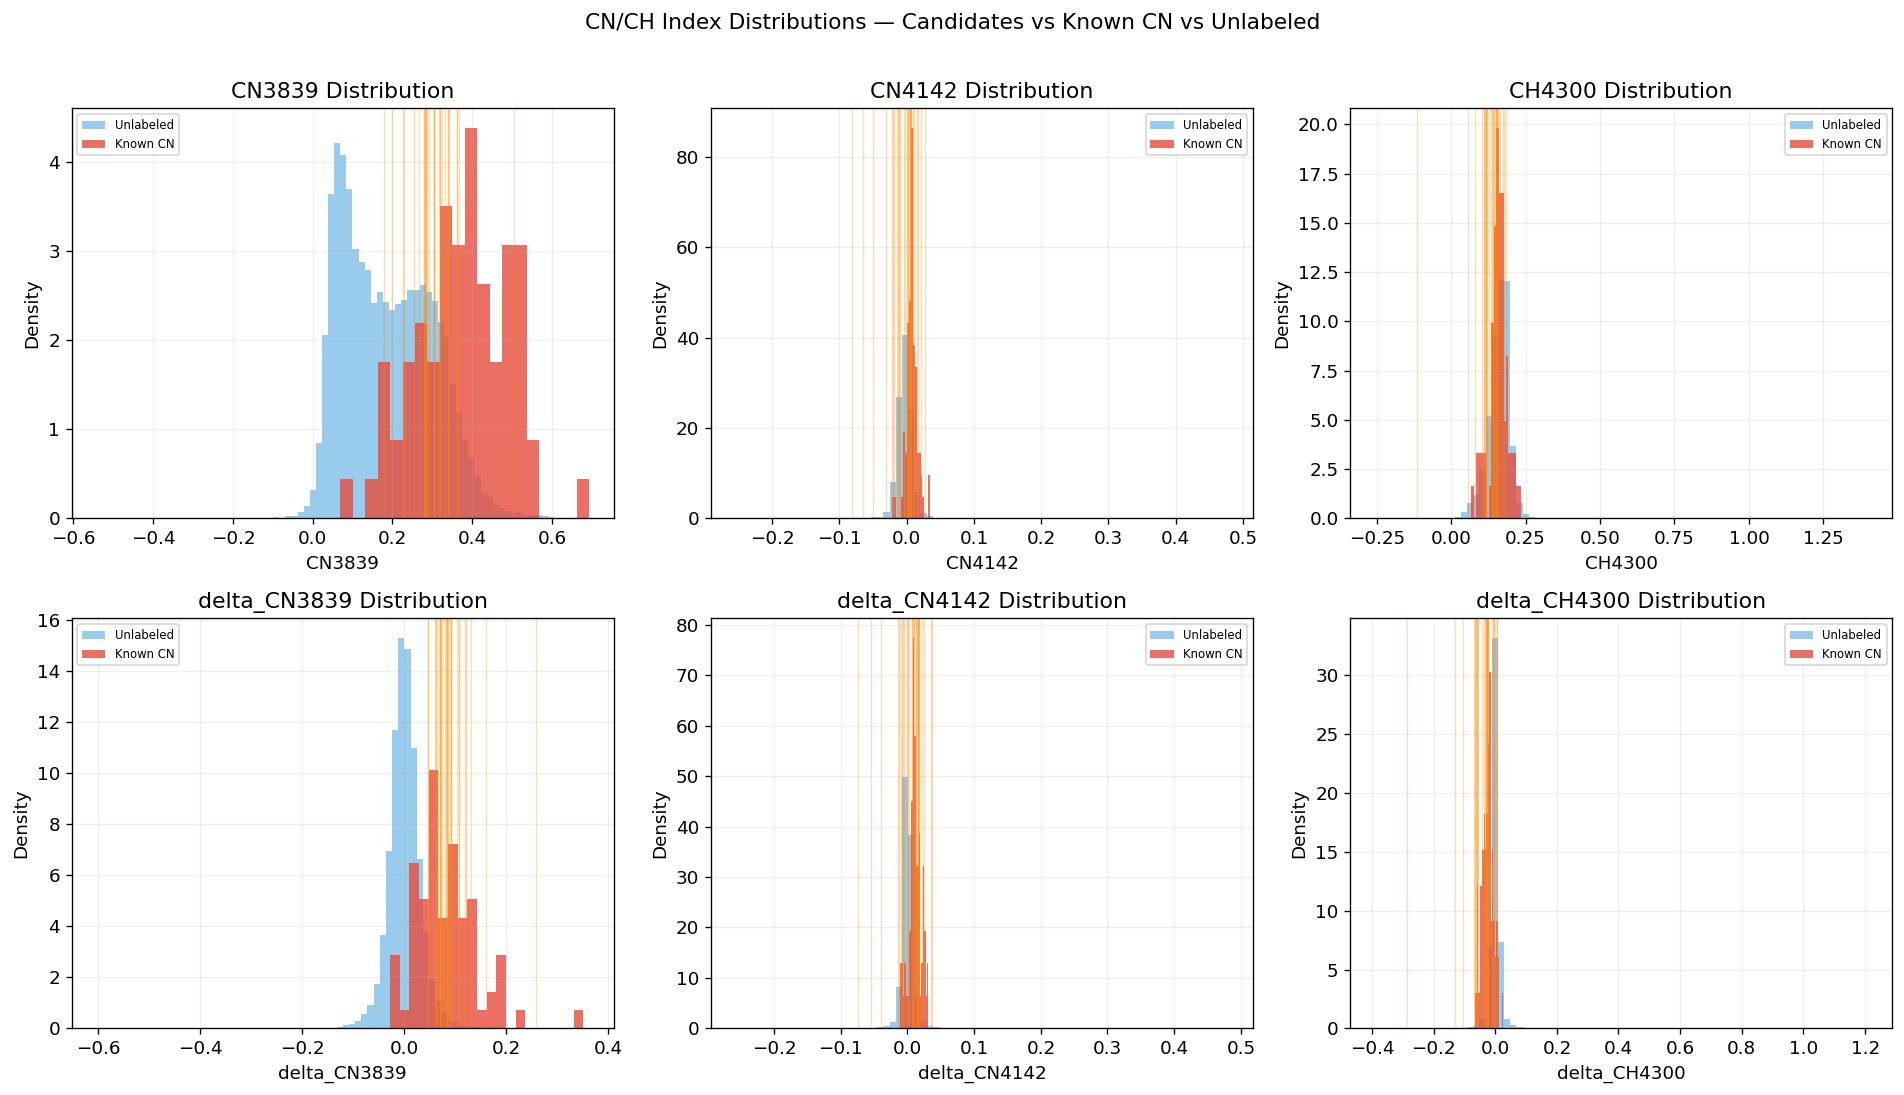

Candidate CN index statistics vs Known CN stars:
  CN3839              : Known=+0.3744, Candidates=+0.3022
  CN4142              : Known=+0.0079, Candidates=-0.0069
  CH4300              : Known=+0.1578, Candidates=+0.1267
  delta_CN3839        : Known=+0.0823, Candidates=+0.0914
  delta_CN4142        : Known=+0.0114, Candidates=+0.0025
  delta_CH4300        : Known=-0.0243, Candidates=-0.0470


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cand_mask = np.zeros(len(y_all), dtype=bool)
cand_mask[top_global_idx] = True

for i, col in enumerate(['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']):
    ax = axes[i // 3, i % 3]
    if col not in df_model.columns:
        continue
    vals = df_model[col].values

    ax.hist(vals[y_all == 0], bins=80, alpha=0.5, density=True, color='#3498db', label='Unlabeled')
    ax.hist(vals[y_all == 1], bins=20, alpha=0.8, density=True, color='#e74c3c', label='Known CN')

    cand_vals = vals[cand_mask]
    for v in cand_vals:
        ax.axvline(x=v, color='darkorange', alpha=0.3, linewidth=0.8)

    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.set_title(f'{col} Distribution')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle('CN/CH Index Distributions — Candidates vs Known CN vs Unlabeled', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Candidate CN index statistics vs Known CN stars:')
for col in ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']:
    if col in df_model.columns:
        known_mean = df_model.loc[y_all == 1, col].mean()
        cand_mean = df_model.loc[cand_mask, col].mean()
        print(f'  {col:20s}: Known={known_mean:+.4f}, Candidates={cand_mean:+.4f}')

## 3. 总结

| 决策 | 最优选择 | 依据 |
|---|---|---|
| 特征集 | **CN 9-D** (CN3839/4142/CH4300 + delta + PCA) | 手工特征中最优 |
| 损失函数 | **Focal Loss γ=1.5** | PR=0.259, 偏见可控, within-r=0.456 |
| 后处理 | **Cluster Z-Score** | 消除簇间系统性偏差 |

**关键局限**: PR=0.259 远低于原始光谱 PU-Bagging (0.848)。9 维手工特征信息损失严重 — 700 像素包含 CN 带形状、线比、同位素特征和连续谱斜率，远超三个简单积分比。

**候选星选择策略**:
1. z-score ≥ 3.0 → 高置信 CN 候选
2. z-score ≥ 2.0 → 可复查候选
3. 同时检查 delta_CN3839 是否偏高